# Groep G09
**Naam:** Arne Bogaert  
**Studentennummer:** 399518ab

### Overzicht van de analyses
* **Reeks 1:** Analyse 2
* **Reeks 2:** Analyse 3
* **Reeks 3:** Analyse 1

## Reeks 1 Analyse 2

In deze analyse bekijken we het gemiddeld aantal fietsers per dag over alle telpalen heen. Voor deze oplossing gebruiken we gegevens uit `FactCountings` en `DimDate`.

Uit `FactCountings` gebruiken we `TotalCounts`, omdat dit het totaal aantal getelde fietsers bevat. Via `DateKey` koppelen we die tellingen aan `DimDate`, zodat we per dagnaam kunnen groeperen met `DutchDayNameOfWeek`. Op die manier kunnen we vergelijken op welke dagen van de week het gemiddeld drukker of rustiger is.


We beginnen met de imports en maken meteen ook de connectie met de DWH, zodat de query daaronder meteen uitgevoerd kan worden.


In [4]:
from pathlib import Path
import sys

import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import text

ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / 'DWH').exists():
    ROOT = ROOT.parent

if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

from DWH.connection.connect import get_engine, getData

engine = get_engine()


Daarna stellen we de query op. We berekenen per dagnaam het gemiddelde van `TotalCounts`, zodat we het algemene patroon over de week kunnen zien.


In [5]:
query = """
    select dd.dutchDayNameOfWeek, avg(totalcounts) as avgBikers 
    from FactCountings fc
    join DimDate dd on dd.DateKey = fc.DateKey
    group by dd.dutchDayNameOfWeek
"""

Nu voeren we de query uit en laden we het resultaat in een DataFrame.


In [6]:
df = getData(engine=engine, query=query)
df.head()

,dutchDayNameOfWeek,avgBikers
0,donderdag,881
1,dinsdag,904
2,zondag,639
3,maandag,830
4,woensdag,898


Om de grafiek leesbaar te maken, zetten we de dagen van de week eerst in de juiste chronologische volgorde.


In [7]:
ordered = ['maandag', 'dinsdag', 'woensdag', 'donderdag', 'vrijdag', 'zaterdag', 'zondag']
df['dutchDayNameOfWeek'] = pd.Categorical(df['dutchDayNameOfWeek'], categories=ordered, ordered=True)
df = df.sort_values('dutchDayNameOfWeek')
df

,dutchDayNameOfWeek,avgBikers
3,maandag,830
1,dinsdag,904
4,woensdag,898
0,donderdag,881
6,vrijdag,834
5,zaterdag,647
2,zondag,639


Tot slot visualiseren we de gemiddelden in een staafdiagram.


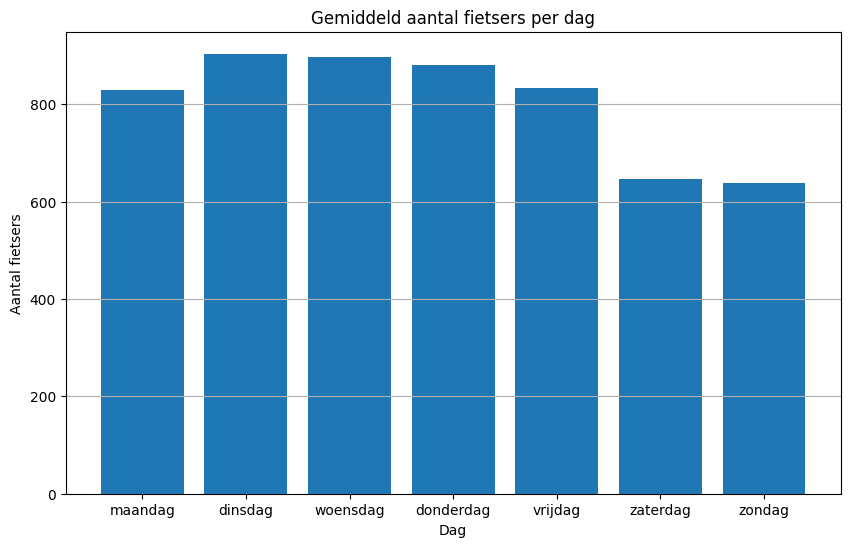

In [8]:
plt.figure(figsize=(10, 6))
plt.bar(x=df['dutchDayNameOfWeek'],height=df['avgBikers'])
plt.grid(axis="y")
plt.title("Gemiddeld aantal fietsers per dag")
plt.xlabel("Dag")
plt.ylabel("Aantal fietsers")
plt.show()

# FINALE ANALYSE

## Analyse van het gemiddeld aantal fietsers per dag

Deze analyse toont hoe het fietsverkeer over de week verdeeld is wanneer we alle telpalen samen bekijken. Door per dagnaam het gemiddelde van `TotalCounts` te berekenen, krijgen we een algemeen beeld van de drukte per weekdag.

De grafiek toont duidelijk dat het fietsverkeer in de week drukker is dan in de week

# ---------------------------------------------------


## Reeks 2 Analyse 3

In deze analyse bekijken we het gebruik van de Blue-bike punten per week. Daarvoor halen we data op uit `FactBlueBike`, `DimDate` en `DimBlueBikeStation`.

Uit `FactBlueBike` gebruiken we de station- en datumsleutels en de kolom `BikesInUse`. Die kolom gebruiken we niet als rechtstreeks aantal uitleningen, maar als basis om nieuwe uitleningen te benaderen via veranderingen tussen opeenvolgende meetmomenten. Als we dit niet zouden doen zouden we te grote getallen krijgen omdat we op elke meetmoment alle fietsen optellen. Uit `DimDate` halen we de kalenderinformatie die nodig is om per week te groeperen, zoals de datum, week en het jaar. Uit `DimBlueBikeStation` halen we de naam of identificatie van het Blue-bike punt, zodat we de resultaten per locatie kunnen interpreteren.

Deze combinatie van tabellen is nodig omdat we zowel een gebruiksmaat, een tijdsdimensie en een locatiedimensie nodig hebben om het geschatte totaal aantal uitleningen per week te analyseren en later te vergelijken tussen Blue-bike punten.

We beginnen opnieuw met de imports die we nodig hebben voor deze analyse.

In [9]:
# Imports voor Reeks 2 Analyse 3
from pathlib import Path
import sys

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sqlalchemy import text
from scipy import stats

ROOT = Path.cwd().resolve()
while ROOT.name != "data-engineering-project-i-2025-2026-g09-1" and ROOT.parent != ROOT:
    ROOT = ROOT.parent

if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

from DWH.connection.connect import get_engine, getData

Nu maken we opnieuw eerst een kleine testquery om te controleren of we de Blue-bike data correct uit de DWH kunnen ophalen.

In [10]:
engine = get_engine()

test_query_bluebike = ("""
SELECT TOP 5 *
FROM FactBlueBike
ORDER BY DateKey DESC, TimeKey DESC
""")

df_test_bluebike = getData(engine, test_query_bluebike)
df_test_bluebike

,BlueBikeStationKey,DateKey,TimeKey,TotalBikesAvailable,EBikesAvailable,BlueBikesAvailable,MaxCapacity,BikesDefect,BikesInUse,LinkedStationKey
0,48,20260427,1345,38,3,35,74,2,35,1
1,50,20260427,1345,16,3,13,185,7,149,3
2,49,20260427,1345,16,0,16,12,6,7,2
3,51,20260427,1345,9,0,9,16,1,3,4
4,53,20260427,1345,25,4,21,70,2,38,6


Nu halen we alle relevante Blue-bike data op die we nodig hebben om per week te analyseren hoeveel gebruik er is per station.

In [ ]:
query_bluebike = ("""
SELECT
    fb.BlueBikeStationKey,
    dbs.LocationName,
    fb.DateKey,
    dd.FullDateAlternateKey AS datum,
    dd.WeekOfYear,
    dd.Year,
    fb.TimeKey,
    fb.BikesInUse,
    fb.TotalBikesAvailable,
    fb.BlueBikesAvailable,
    fb.EBikesAvailable
FROM FactBlueBike AS fb
LEFT JOIN DimDate AS dd
    ON fb.DateKey = dd.DateKey
LEFT JOIN DimBlueBikeStation AS dbs
    ON fb.BlueBikeStationKey = dbs.BlueBikeStationKey
ORDER BY dd.FullDateAlternateKey, fb.TimeKey, dbs.LocationName
""")

df_bluebike = getData(engine, query_bluebike)

if df_bluebike is None:
    raise ValueError("De query is mislukt")

df_bluebike.head()

Voor we verder gaan, controleren we eerst of de kolom `BikesInUse` effectief waarden bevat of overal leeg is.

In [9]:
print('Aantal rijen totaal:', len(df_bluebike))
print('Aantal niet-lege BikesInUse waarden:', df_bluebike['BikesInUse'].notna().sum())
print('Aantal lege BikesInUse waarden:', df_bluebike['BikesInUse'].isna().sum())
print('Eerste niet-lege BikesInUse waarden:')
print(df_bluebike['BikesInUse'].dropna().head(10))

df_bluebike[df_bluebike['BikesInUse'].notna()].head()

Aantal rijen totaal: 792919
Aantal niet-lege BikesInUse waarden: 772694
Aantal lege BikesInUse waarden: 20225
Eerste niet-lege BikesInUse waarden:
17136     2.0
17137     0.0
17138     0.0
17139     2.0
17140     0.0
17141     2.0
17142    13.0
17143     5.0
17144    11.0
17145     0.0
Name: BikesInUse, dtype: float64


,BlueBikeStationKey,LocationName,DateKey,datum,WeekOfYear,Year,TimeKey,BikesInUse,TotalBikesAvailable,BlueBikesAvailable,EBikesAvailable
17136,81,Aalst Station,20260313,2026-03-13,11,2026,1920,2.0,13,13,0
17137,214,Aalst Station Denderzijde,20260313,2026-03-13,11,2026,1920,0.0,6,6,0
17138,279,Aalter Centrum,20260313,2026-03-13,11,2026,1920,0.0,7,5,2
17139,117,Aalter Station,20260313,2026-03-13,11,2026,1920,2.0,10,8,2
17140,51,Aarschot Station,20260313,2026-03-13,11,2026,1920,0.0,17,13,4


Er zijn 20000 BikesInUse waarden die waarde NULL hebben omdat we de BikesInUse kolom pas later hebben toegevoegd

Nu filteren we eerst de rijen weg waar `BikesInUse` geen waarde heeft, zodat we alleen met bruikbare waarnemingen verder werken.

In [10]:
df_bluebike_clean = df_bluebike[df_bluebike['BikesInUse'].notna()].copy()

print('Aantal rijen na filtering:', len(df_bluebike_clean))
df_bluebike_clean.head()

Aantal rijen na filtering: 772694


,BlueBikeStationKey,LocationName,DateKey,datum,WeekOfYear,Year,TimeKey,BikesInUse,TotalBikesAvailable,BlueBikesAvailable,EBikesAvailable
17136,81,Aalst Station,20260313,2026-03-13,11,2026,1920,2.0,13,13,0
17137,214,Aalst Station Denderzijde,20260313,2026-03-13,11,2026,1920,0.0,6,6,0
17138,279,Aalter Centrum,20260313,2026-03-13,11,2026,1920,0.0,7,5,2
17139,117,Aalter Station,20260313,2026-03-13,11,2026,1920,2.0,10,8,2
17140,51,Aarschot Station,20260313,2026-03-13,11,2026,1920,0.0,17,13,4


Daarna schatten we per Blue-bike station en per week het aantal nieuwe uitleningen. We doen dit niet door `BikesInUse` zomaar op te tellen, want dat zou dezelfde fietsen op meerdere meetmomenten opnieuw meetellen.

In plaats daarvan kijken we per station naar het verschil in `BikesInUse` tussen twee opeenvolgende meetmomenten. Alleen wanneer dit verschil positief is, interpreteren we dat als nieuwe uitleningen. Die positieve stijgingen tellen we daarna per week op.

Deze aanpak blijft een benadering, maar ligt veel dichter bij het werkelijke aantal uitleningen per week dan het rechtstreeks sommeren van alle momentopnames.

In [ ]:
# Geschatte uitleningen per station per week berekenen
df_bluebike_clean = df_bluebike_clean.sort_values(['BlueBikeStationKey', 'DateKey', 'TimeKey']).copy()

# Verandering in BikesInUse tussen twee opeenvolgende meetmomenten per station
df_bluebike_clean['VerschilBikesInUse'] = (
    df_bluebike_clean.groupby('BlueBikeStationKey')['BikesInUse'].diff()
)

# Alleen positieve stijgingen interpreteren we als nieuwe uitleningen
df_bluebike_clean['NieuweUitleningen'] = (
    df_bluebike_clean['VerschilBikesInUse'].clip(lower=0).fillna(0)
)

# Nieuwe dataframe om de data netjes te ordenen
bluebike_per_week = (
    df_bluebike_clean.groupby(
        ['BlueBikeStationKey', 'LocationName', 'Year', 'WeekOfYear'],
        as_index=False
    )['NieuweUitleningen']
    .sum()
    .rename(columns={'NieuweUitleningen': 'GeschatAantalUitleningenPerWeek'})
    .sort_values(['LocationName', 'Year', 'WeekOfYear'])
)

bluebike_per_week.head()

,BlueBikeStationKey,LocationName,Year,WeekOfYear,GeschatAantalUitleningenPerWeek
116,81,Aalst Station,2026,11,0.0
117,81,Aalst Station,2026,12,15.0
118,81,Aalst Station,2026,13,68.0
119,81,Aalst Station,2026,14,10.0
456,214,Aalst Station Denderzijde,2026,11,0.0


Nu berekenen we voor elk Blue-bike station het gemiddeld geschat aantal uitleningen per week.

In [ ]:
gemiddeld_per_station = (
    bluebike_per_week.groupby(['BlueBikeStationKey', 'LocationName'], as_index=False)['GeschatAantalUitleningenPerWeek']
    .mean()
    .rename(columns={'GeschatAantalUitleningenPerWeek': 'GemiddeldAantalUitleningenPerWeek'})
    .sort_values('GemiddeldAantalUitleningenPerWeek', ascending=False)
)

gemiddeld_per_station.head()

,BlueBikeStationKey,LocationName,GemiddeldAantalUitleningenPerWeek
2,50,Leuven Station Tiensevest,295.00
21,73,Gent-Sint-Pieters Station St-Denijs,236.75
20,72,Gent-Dampoort Station,206.25
10,61,Deinze Station,181.25
59,133,Gent-Sint-Pieters Station Hendrika,153.75


Nu kunnen we een histogram maken van het gemiddeld aantal uitleningen per week per station. Zo zien we hoe het gebruik verdeeld is over alle Blue-bike punten.

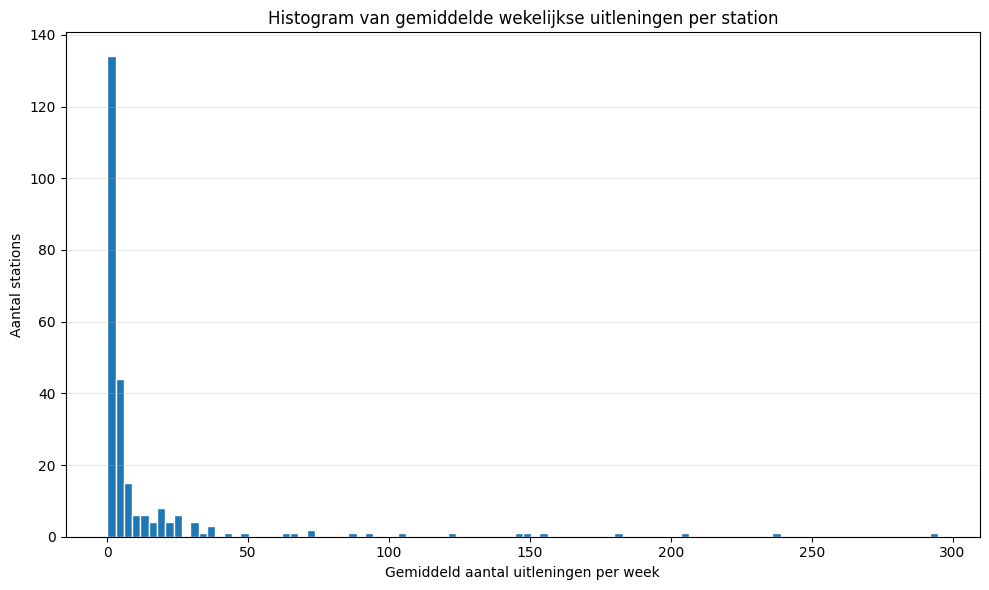

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(
    gemiddeld_per_station['GemiddeldAantalUitleningenPerWeek'],
    bins=50,
    edgecolor='white'
)
plt.title('Histogram van gemiddelde wekelijkse uitleningen per station')
plt.xlabel('Gemiddeld aantal uitleningen per week')
plt.ylabel('Aantal stations')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretatie van de verdeling

De verdeling van het gemiddeld aantal uitleningen per week per station is duidelijk rechts-scheef. We zien dat de meeste Blue-bike stations een relatief laag gemiddeld aantal uitleningen per week hebben, terwijl een klein aantal stations veel hogere waarden haalt. Daardoor ontstaat een lange staart naar rechts.

Dit betekent dat de verdeling geen normale verdeling is. Bij een normale verdeling zouden de waarden symmetrisch rond het gemiddelde liggen, wat hier duidelijk niet het geval is.

De verdeling lijkt ook niet op een zuivere Poisson-verdeling. Een Poisson-verdeling wordt typisch gebruikt voor tellingen van gebeurtenissen in een vaste tijdseenheid, maar hier werken we met gemiddelden per station over meerdere weken. Daardoor is de verdeling eerder te beschrijven als een rechts-scheve long-tail verdeling.

Kort samengevat: de meeste stations worden beperkt gebruikt, terwijl een kleine groep stations veel intensiever gebruikt wordt.

### Functie om de top-% te bepalen

Met deze functie bepalen we tot welke top-% meest gebruikte Blue-bike punten een station behoort. We doen dit op basis van de rangorde van alle stations in de dataset: hoe hoger het gemiddeld aantal uitleningen per week, hoe hoger het station in de ranking staat.

In [ ]:
def bereken_top_percentage(station_naam, data=gemiddeld_per_station):
    station_data = data[data['LocationName'] == station_naam]

    if station_data.empty:
        raise ValueError(f"Station '{station_naam}' niet gevonden in gemiddeld_per_station.")

    rang = data['GemiddeldAantalUitleningenPerWeek'].rank(ascending=False, method='min').loc[station_data.index[0]]
    totaal_stations = len(data)
    top_percentage = (rang / totaal_stations) * 100
    gemiddelde = station_data['GemiddeldAantalUitleningenPerWeek'].iloc[0]

    resultaat = {
        'LocationName': station_naam,
        'GemiddeldAantalUitleningenPerWeek': gemiddelde,
        'Rang': int(rang),
        'AantalStations': totaal_stations,
        'TopPercentage': top_percentage,
        'Boodschap': f"{station_naam} behoort tot de top {top_percentage:.1f}% meest gebruikte Blue-bike punten."
    }

    return resultaat


voorbeeld_station = 'Gent-Dampoort Station'
resultaat_station = bereken_top_percentage(voorbeeld_station)
print(resultaat_station['Boodschap'])
resultaat_station

Gent-Dampoort Station behoort tot de top 1.2% meest gebruikte Blue-bike punten.


{'LocationName': 'Gent-Dampoort Station',
 'GemiddeldAantalUitleningenPerWeek': np.float64(244.66666666666666),
 'Rang': 3,
 'AantalStations': 252,
 'TopPercentage': np.float64(1.1904761904761905),
 'Boodschap': 'Gent-Dampoort Station behoort tot de top 1.2% meest gebruikte Blue-bike punten.'}

# FINALE ANALYSE

## Analyse van de wekelijkse Blue-bike uitleningen

![Histogram Blue-bike](../images/Analyses_Arne_Fotos/HistogramBlueBike.png)

De analyse toont dat het gebruik van Blue-bike stations zeer ongelijk verdeeld is. De meeste stations hebben een relatief laag gemiddeld aantal uitleningen per week, terwijl een kleine groep stations veel intensiever gebruikt wordt. Dit zien we duidelijk in het histogram, waar de meeste observaties zich links bevinden en er een lange staart naar rechts loopt.

Deze verdeling is dus rechts-scheef en geen normale verdeling. Dat betekent dat enkele drukke stations het algemene beeld sterk beïnvloeden en dat we stations best niet alleen op basis van een algemeen gemiddelde beoordelen.

## Analyse van de top-% meest gebruikte Blue-bike punten

Met de functie `bereken_top_percentage()` kunnen we per station bepalen tot welke top-% meest gebruikte Blue-bike punten het behoort. We doen dit op basis van de rangorde van alle stations volgens hun gemiddeld aantal uitleningen per week. Daardoor krijgen we een duidelijk en interpreteerbaar resultaat dat toont hoe sterk een station gebruikt wordt in vergelijking met de rest van de dataset.

Deze aanpak past goed bij de vorm van de data, omdat een ranking beter werkt dan een vergelijking met een normale verdeling. Zo kunnen we bijvoorbeeld aangeven dat een station tot de top 5%, top 10% of top 25% meest gebruikte Blue-bike punten behoort.

# Einde Reeks 2 Analyse 3

---------------------------------------------

# Reeks 3 Analyse 1

In deze analyse onderzoeken we het aantal dagen met regen per provincie. Daarvoor gebruiken we gegevens uit `FactMeteo`, `DimWeatherStation`, `DimLocation` en `DimDate`.

Uit `FactMeteo` halen we de neerslagwaarde `PrecipQuantity`, omdat die bepaalt of er op een bepaalde dag regen viel. Via `DimWeatherStation` en `DimLocation` koppelen we elke meting aan een provincie. Met `DimDate` kunnen we de metingen per kalenderdag samenbrengen.

Het doel is om per provincie te bepalen op hoeveel dagen er regen was, dit visueel weer te geven in een grafiek, en daarna statistisch te onderzoeken of de verschillen tussen de provincies significant zijn.

In [14]:
from pathlib import Path
import sys

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sqlalchemy import text
from scipy import stats

ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / 'DWH').exists():
    ROOT = ROOT.parent

if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

from DWH.connection.connect import get_engine, getData

Zoals gewoonlijk maken we eerst een testquery om de connectie te testen

In [15]:
engine = get_engine()

test_query_meteo = ("""
SELECT TOP 5 *
FROM FactMeteo
ORDER BY DateKey DESC
""")

df_test_meteo = getData(engine, test_query_meteo)
df_test_meteo

,MeteoKey,DateKey,WeatherStationKey,PrecipQuantity,TempAvg,TempMax,TempMin,TempGrassPt100Avg,TempSoilAvg,TempSoilAvg5cm,...,TempSoilAvg20cm,TempSoilAvg50cm,WindSpeed10m,WindSpeedAvg30m,WindGustsSpeed,HumidityRelShelterAvg,Pressure,SunDuration,ShortWaveFromSkyAvg,SunIntAvg
0,71322,20260329,6438,1.46,6.63,10.70,0.45,6.94,7.53,7.86,...,7.07,8.35,4.62,NaN,16.23,78.53,1026.96,404.75,162.28,233.88
1,71323,20260329,6484,0.00,4.71,9.49,-1.27,15.26,6.65,6.33,...,6.29,7.12,2.52,NaN,8.84,68.03,989.11,338.17,157.01,161.22
2,71324,20260329,6434,2.08,6.67,10.83,0.84,9.06,8.53,7.96,...,7.76,8.32,4.02,4.84,12.97,77.38,1026.13,445.08,171.61,200.92
3,71325,20260329,6472,1.29,4.97,9.49,0.49,8.55,6.76,6.91,...,6.48,6.98,3.36,4.05,16.63,73.36,992.24,401.92,174.56,172.17
4,71326,20260329,6494,1.00,2.06,6.23,-0.59,0.72,5.73,5.18,...,3.72,4.55,3.40,NaN,14.48,81.05,946.38,296.92,183.98,162.68


Daarna gaan we de effectieve data ophalen die we nodig hebben voor de analyse. We halen datum, Province, WeatherStationKey, WeatherStationName en PrecipQuantity op via een JOIN tussen FactMeteo, DimDate, DimWeatherStation en DimLocation.

In [16]:
query_meteo = ("""
SELECT
    fm.DateKey,
    dd.FullDateAlternateKey AS datum,
    ws.WeatherStationID,
    ws.Name AS WeatherStationName,
    ws.LocationKey,
    dl.Province,
    fm.PrecipQuantity
FROM FactMeteo AS fm
LEFT JOIN DimDate AS dd
    ON fm.DateKey = dd.DateKey
LEFT JOIN DimWeatherStation AS ws
    ON fm.WeatherStationKey = ws.WeatherStationID
LEFT JOIN DimLocation AS dl
    ON ws.LocationKey = dl.LocationKey
WHERE dl.Province IS NOT NULL
ORDER BY fm.DateKey DESC, ws.WeatherStationID
""")

df_meteo = getData(engine, query_meteo)

if df_meteo is None:
    raise ValueError("De query is mislukt. Kijk naar de foutmelding boven deze cel.")

df_meteo.head()


,DateKey,datum,WeatherStationID,WeatherStationName,LocationKey,Province,PrecipQuantity
0,20260329,2026-03-29,6414,BEITEM,2403,West-Vlaanderen,1.84
1,20260329,2026-03-29,6418,ZEEBRUGGE,2246,West-Vlaanderen,0.61
2,20260329,2026-03-29,6434,MELLE,2485,Oost-Vlaanderen,2.08
3,20260329,2026-03-29,6438,STABROEK,417,Antwerpen,1.46
4,20260329,2026-03-29,6439,SINT-KATELIJNE-WAVER,400,Antwerpen,1.20


Nu we de data hebben gaan we een nieuw dataframe maken waar we de Provincies groeperen op Provincie en datum. Daarna voegen we een nieuwe tabel kolom 'regen' toe die True geeft als PrecipQuantity op die datum groter is dan 0.

In [18]:
df_meteo['datum'] = pd.to_datetime(df_meteo['datum'])
df_meteo['regen'] = df_meteo['PrecipQuantity'].fillna(0) > 0

regen_per_provincie_dag = (
    df_meteo.groupby(['Province', 'datum'], as_index=False)['regen']
    .max()
    .sort_values(['Province', 'datum'])
)

regen_per_provincie_dag.head()

,Province,datum,regen
0,Antwerpen,2019-12-31,True
1,Antwerpen,2020-01-01,False
2,Antwerpen,2020-01-02,True
3,Antwerpen,2020-01-03,True
4,Antwerpen,2020-01-04,True


Nu we deze data hebben kunnen we al deze dagen per provincie optellen en in een nieuwe dataframe steken

In [19]:
regen_telling_per_provincie = (
    regen_per_provincie_dag.groupby(['Province', 'regen'])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

regen_telling_per_provincie

regen,Province,False,True
0,Antwerpen,709,1571
1,Limburg,926,1354
2,Oost-Vlaanderen,925,1355
3,Vlaams-Brabant,993,1287
4,West-Vlaanderen,515,1765


Nu hebben we een opgeschoonde dataframe met alle regendagen per provincie opgeteld. Nu we dit hebben kunnen we een plot maken om de data te visualiseren

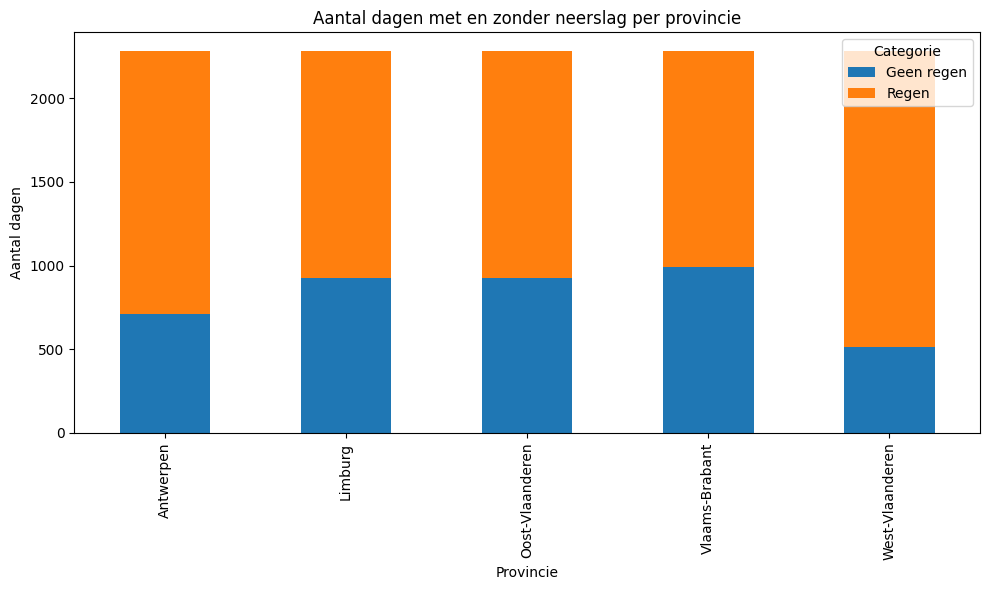

In [20]:
plot_data = (
    regen_telling_per_provincie
    .set_index('Province')
    .reindex(columns=[False, True], fill_value=0)
    .rename(columns={False: 'Geen regen', True: 'Regen'})
)

plot_data.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6),
    color=['tab:blue', 'tab:orange']
)

plt.title('Aantal dagen met en zonder neerslag per provincie')
plt.xlabel('Provincie')
plt.ylabel('Aantal dagen')
plt.xticks(rotation=90)
plt.legend(title='Categorie')
plt.tight_layout()
plt.show()

Nu we de plot hebben kunnen we ook eens kijken of er significante verschillen zijn tussen de provoncies. We gaan voor elke provincie het aantalRegendagen delen door het totaalaantal dagen * 100.

In [21]:
regen_percentage_per_provincie = regen_per_provincie_dag.groupby('Province')['regen'].agg(
    AantalRegendagen='sum',
    TotaalAantalDagen='count'
).reset_index()

regen_percentage_per_provincie['PercentageRegendagen'] = (
    regen_percentage_per_provincie['AantalRegendagen']
    / regen_percentage_per_provincie['TotaalAantalDagen']
    * 100
)

regen_percentage_per_provincie.sort_values('PercentageRegendagen', ascending=False)


,Province,AantalRegendagen,TotaalAantalDagen,PercentageRegendagen
4,West-Vlaanderen,1765,2280,77.412281
0,Antwerpen,1571,2280,68.903509
2,Oost-Vlaanderen,1355,2280,59.429825
1,Limburg,1354,2280,59.385965
3,Vlaams-Brabant,1287,2280,56.447368


# FINALE ANALYSE

## Analyse van het aantal regendagen per provincie

Op basis van het percentage regendagen zien we duidelijke verschillen tussen de provincies die in onze DWH zitten. West-Vlaanderen heeft met ongeveer 77,4% het hoogste aantal regendagen en is dus de natste provincie. Antwerpen volgt met ongeveer 68,9%, terwijl Oost-Vlaanderen en Limburg bijna gelijk scoren met ongeveer 59,4%. Brussel heeft met ongeveer 56,4% het laagste percentage regendagen van de beschikbare provincies.

Dit betekent dat er wel degelijk merkbare verschillen zijn in het aantal dagen met regen tussen de provincies in onze dataset. Vooral West-Vlaanderen wijkt duidelijk af van de andere provincies en kent relatief veel meer regendagen.

# Einde Analyses